In [1]:
from omero.gateway import BlitzGateway
from omero.model import RenderingDefI
import matplotlib.pyplot as plt

In [41]:
USERNAME = 'username'
PASSWORD = 'pass'
HOST = 'omero.natur.biocev.org'
PORT = 4064
GROUP = 'CockovaIMCF'

In [81]:
conn = BlitzGateway(USERNAME, PASSWORD, host=HOST, port=PORT, group=GROUP, secure=True)
conn.connect()

True

<_ImageWrapper id=17179>
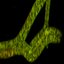

In [82]:
image_id = 17179  # Replace with your image ID
image = conn.getObject("Image", image_id)

image

In [83]:
print("Rendering Defs on Image:")
for rdef in image.getAllRenderingDefs():
    img_data = image.getThumbnail(rdefId=rdef['id'])
    print("   ID: %s (owner: %s %s)" % (
        rdef['id'], rdef['owner']['firstName'], rdef['owner']['lastName']))

Rendering Defs on Image:
   ID: 16829 (owner: Zuzana Čočková)


In [62]:
# List Channels (loads the Rendering settings to get channel colors)
for channel in image.getChannels():
    print('Name', channel.getName())
    print('Channel:', channel.getLabel())
    print('Color:', channel.getColor().getRGB())
    print('Lookup table:', channel.getLut())
    (channel.setLookupTable('16_colors'))
    #channel.save()
    print('Lookup table:', channel.getLut())

    print('Is reverse intensity?', channel.isReverseIntensity())

Name None
Channel: 0
Color: (255, 0, 0)
Lookup table: 16_colors.lut
Lookup table: 16_colors.lut
Is reverse intensity? False
Name None
Channel: 1
Color: (0, 255, 0)
Lookup table: None
Lookup table: None
Is reverse intensity? False
Name None
Channel: 2
Color: (0, 0, 255)
Lookup table: None
Lookup table: None
Is reverse intensity? False


In [95]:
image.setColorRenderingModel()
channels = [0,1,2,3]
color_list = ['FF00FF', '00FF00','FF0000', '00FFFF']  # do not change color of 2nd channel
range_list = [[100.0, 120.2], [None, None], [100.0, 120.2], [100.0, 120.2]]
image.setActiveChannels(channels, colors=color_list, windows=range_list)
image.saveDefaults()
#image.resetDefaults(save=True)


True

In [109]:
conn.close()

ConnectionLostException: Ice.ConnectionLostException:
recv() returned zero

In [110]:
USERNAME = 'cockovaz'
PASSWORD = 'Lok0motiva'
HOST = 'omero.natur.biocev.org'
PORT = 4064
GROUP = 'Marekova 2023'

conn = BlitzGateway(USERNAME, PASSWORD, host=HOST, port=PORT, group=GROUP, secure=True)
conn.connect()

True

<_ImageWrapper id=22563>
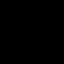

In [111]:
image_id = 22563  # Replace with your image ID
image = conn.getObject("Image", image_id)

image 

In [124]:
print("Channel rendering settings:")
channel_list = []
channel_names = []
for i,ch in enumerate(image.getChannels()):
    channel_list.append(i+1)
    channel_names.append(ch.getLabel())


print(channel_list)
print(channel_names)

Channel rendering settings:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
['415', '424', '432', '441', '450', '459', '468', '477', '486', '495', '504', '512', '521', '530', '539', '548', '557', '566', '575', '584', '592', '601', '610', '619', '628', '637', '646', '655', '664', '672', '681', '690']


In [ ]:
range_list = [[100.0, 120.2], [None, None], [100.0, 120.2], [100.0, 120.2]]

In [122]:
hex_codes = [
    "7D00FF",  # 415 nm - Violet
    "6A00FF",  # 424 nm - Indigo
    "6100FF",  # 432 nm - Indigo
    "4C00FF",  # 441 nm - Blue-Violet
    "0000FF",  # 450 nm - Deep Blue
    "0033FF",  # 459 nm - Bright Blue
    "007FFF",  # 468 nm - Sky Blue
    "0099FF",  # 477 nm - Light Blue
    "00CCFF",  # 486 nm - Cyan Blue
    "00FFFF",  # 495 nm - Cyan
    "33FFCC",  # 504 nm - Greenish Cyan
    "00FF99",  # 512 nm - Aqua Green
    "00FF66",  # 521 nm - Mint Green
    "00FF00",  # 530 nm - Green
    "66FF00",  # 539 nm - Bright Green
    "99FF00",  # 548 nm - Yellow-Green
    "CCFF00",  # 557 nm - Lime Green
    "EEFF00",  # 566 nm - Yellow-Lime
    "FFFF00",  # 575 nm - Yellow
    "FFDD00",  # 584 nm - Light Yellow
    "FFBB00",  # 592 nm - Yellow-Orange
    "FF9900",  # 601 nm - Orange
    "FF7700",  # 610 nm - Orange-Red
    "FF5500",  # 619 nm - Reddish Orange
    "FF3300",  # 628 nm - Red-Orange
    "FF0000",  # 637 nm - Deep Red
    "CC0000",  # 646 nm - Crimson Red
    "990000",  # 655 nm - Dark Red
    "770000",  # 664 nm - Burgundy
    "550000",  # 672 nm - Deep Burgundy
    "330000",  # 681 nm - Dark Maroon
    "220000"   # 690 nm - Near Infrared Red
]


In [125]:
image.setColorRenderingModel()
image.setActiveChannels(
    channel_list, 
    colors=hex_codes, 
    #windows=range_list,
    )
image.saveDefaults()
#image.resetDefaults(save=True)


True

In [ ]:
# max intensity projection 'intmean' for mean-intensity
image.setProjection('intmax')
rendered_image = image.renderImage(z, t)  # z and t are ignored for projections
# renderedImage.show()
rendered_image.save("all_channels.jpg")
image.setProjection('normal')               # turn off projection

In [70]:
# Ensure the rendering settings exist
rendering_def = image.getRenderingModel()

# Loop through each channel and modify its color or LUT
for i, channel in enumerate(image.getChannels()):
    print(f"Modifying channel {i + 1}: {channel.getLabel()}")
    
    # Set a custom RGB color (as an example)
    # Example: bright cyan "#00FFFF" (use any valid RGB hex code)
    channel_color = "#00FFFF"  
    #channel.setColor(channel_color)  # Apply the color
    image.setActiveChannels([channel], [channel_color])
    # Set custom intensity window levels (start and end)
    rendering_def.setChannelWindowStart(i, 100)  # Example: Min intensity 100
    rendering_def.setChannelWindowEnd(i, 2000)   # Example: Max intensity 2000

    # Make the channel active
    rendering_def.setActive(i, True)

# Save the rendering settings to the OMERO server
image.saveRenderingDef()
print(f"Rendering settings for image {image_id} updated.")



Modifying channel 1: 0


TypeError: bad operand type for abs(): '_ChannelWrapper'

In [21]:
print("Channel rendering settings:")
for ch in image.getChannels():
    # if no name, get emission wavelength or index
    print("Name: ", ch.getLabel())
    print("  Color:", ch.getColor().getHtml())
    
    print("  Active:", ch.isActive())
    print("  Levels:", ch.getWindowStart(), "-", ch.getWindowEnd())
print("isGreyscaleRenderingModel:", image.isGreyscaleRenderingModel())
print("Default Z/T positions:")
print("    Z = %s, T = %s" % (image.getDefaultZ(), image.getDefaultT()))

Channel rendering settings:
Name:  0
  Color: FF0000
  Active: True
  Levels: 5.0 - 183.0
Name:  1
  Color: 00FF00
  Active: True
  Levels: 0.0 - 469.0
Name:  2
  Color: 0000FF
  Active: True
  Levels: 7.0 - 422.0
isGreyscaleRenderingModel: False
Default Z/T positions:
    Z = 0, T = 0


In [7]:
#image.getHistogram(channels=[0], binCount=255)


In [18]:
rendering_def = image.getRenderingModel()

channel_index = 0  # First channel

# Example custom LUT (black -> blue -> white)
lut = ["#000000", "#0000FF", "#FFFFFF"]

# Get or create the Channel object for the selected channel
pixels = image.getPrimaryPixels()

channel = pixels.getChannel(channel_index)


AttributeError: 'PixelsI' object has no attribute 'name'

<_PixelsWrapper id=1615>

In [ ]:
# Set LUT, intensity start, and end points
channel.setLookupTable(lut)  # Apply LUT
rendering_def.setChannelWindowStart(channel_index, 0)   # Min intensity
rendering_def.setChannelWindowEnd(channel_index, 255)   # Max intensity

# Save the updated rendering definition and channel settings
#conn.getUpdateService().saveObject(rendering_def)
print(f"Custom LUT applied to channel {channel_index} of image {image_id}.")

In [9]:
# Get the rendering definition (for controlling channel appearance)
rendering_def = image.getRenderingDef()
if rendering_def is None:
    image.setRenderingDef(RenderingDefI())  # Create one if it doesn't exist

AttributeError: 'ImageI' object has no attribute 'getRenderingDef'

In [ ]:
# Set LUT for the first channel (index 0)
channel_index = 0

# Define your custom LUT (e.g., black → red → yellow → white)
lut = ["#000000", "#FF0000", "#FFFF00", "#FFFFFF"]  # Example colors

# Apply the custom LUT to the channel
rendering_def.setChannelWindowStart(channel_index, 0)   # Min intensity
rendering_def.setChannelWindowEnd(channel_index, 255)   # Max intensity
rendering_def.setChannelColorLUT(channel_index, lut)

# Save changes to the server
rendering_def.save()


In [ ]:
image.saveRenderingDef()
print(f"LUT applied and saved for image ID: {image_id}")